# Interrupt and Resume [Step 1 - Pausing for Human Input]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to use LangGraph's `interrupt()` function
to pause graph execution and wait for human input, then resume using
`Command(resume=...)`.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for interrupt/resume pattern
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_ollama import ChatOllama

In [4]:
# State schema - includes a field for human responses
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    human_response: str

In [5]:
# Initialize local LLM
llm = ChatOllama(model="llama3.1:8b", temperature=0)

In [6]:
# Draft node - generates a response draft that needs human review
def draft_node(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [7]:
# Human review node - pauses execution and waits for human input
# interrupt() suspends the graph and returns the question to the caller
def human_review_node(state: AgentState):
    last_message = state["messages"][-1].content
    # interrupt() pauses here - execution stops until Command(resume=...) is called
    human_feedback = interrupt(
        f"Please review this response before sending:\n\n{last_message}\n\n"
        "Enter your feedback (or 'approve' to send as-is):"
    )
    # The resumed value is stored in state when execution continues
    return {"human_response": human_feedback}

In [8]:
# Final node - either sends the original or modified response
def final_node(state: AgentState):
    human_response = state.get("human_response", "")
    if human_response.lower() == "approve":
        # Human approved - keep the original response
        return {"messages": [("assistant", "Response approved and sent.")]}

    # Human provided feedback - generate a revised response
    revision_messages = state["messages"] + [
        ("system", f"Human feedback: {human_response}. Please revise your response.")
    ]
    revised = llm.invoke(revision_messages)
    return {"messages": [revised]}

In [9]:
# Build the graph with three nodes in sequence
graph_builder = StateGraph(AgentState)
graph_builder.add_node("draft", draft_node)
graph_builder.add_node("human_review", human_review_node)
graph_builder.add_node("final", final_node)

# Wire the edges: draft -> human_review -> final
graph_builder.add_edge(START, "draft")
graph_builder.add_edge("draft", "human_review")
graph_builder.add_edge("human_review", "final")
graph_builder.add_edge("final", END)

In [10]:
# Compile with checkpointer - required for interrupt to work
checkpointer = MemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

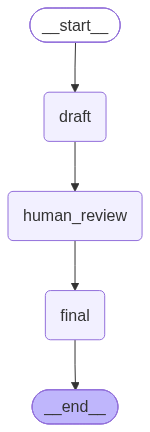

In [11]:
# Visualize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization unavailable: {e}")
    print("Graph nodes: START -> draft -> human_review -> final -> END")

In [12]:
# Thread config for persistence
config = {"configurable": {"thread_id": "interrupt-thread-1"}}

In [13]:
# First invoke - graph runs until interrupt() in human_review
# Returns an interrupt object instead of full output
result = graph.invoke(
    {"messages": [("user", "What is the capital of France?")]},
    config,
)
print("Graph paused at human_review node")
print(f"Result type: {type(result).__name__}")

Graph paused at human_review node
Result type: dict


In [14]:
# Check the current state - execution is paused at human_review
state = graph.get_state(config)
print(f"Next node: {state.next}")
print(f"State values: {list(state.values.keys())}")

Next node: ('human_review',)
State values: ['messages']


In [15]:
# Resume with "approve" - sends the draft as-is
# Command(resume=...) provides the value that interrupt() returns to
result = graph.invoke(Command(resume="approve"), config)
print("\nAfter approval:")
print("Next node:", graph.get_state(config).next)


After approval:
Next node: ()


In [16]:
# Show the final messages in the thread
final_state = graph.get_state(config)
print("\nFinal conversation:")
for msg in final_state.values["messages"]:
    role = msg.type
    content = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
    print(f"  [{role}] {content}")


Final conversation:
  [human] What is the capital of France?
  [ai] The capital of France is Paris.
  [ai] Response approved and sent.


In [17]:
# Run a second example with feedback instead of approval
config2 = {"configurable": {"thread_id": "interrupt-thread-2"}}

# Invoke until interrupt
result = graph.invoke(
    {"messages": [("user", "Explain what Python is.")]}
    , config2,
)
print("Graph paused - waiting for human input")

# Resume with feedback that asks for revision
result = graph.invoke(
    Command(resume="Please make the response shorter and simpler.")
    , config2,
)
print("\nAfter feedback:")
for msg in graph.get_state(config2).values["messages"]:
    role = msg.type
    content = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
    print(f"  [{role}] {content}")

Graph paused - waiting for human input



After feedback:
  [human] Explain what Python is.
  [ai] **What is Python?**

Python is a high-level, interpreted programming language t...
  [ai] assistant

**What is Python?**

Python is a high-level, interpreted programming language that's easy...


In [18]:
# Interrupt/resume summary
print("\nInterrupt/Resume Summary:")
print("  interrupt(value) - pauses graph, returns value to caller")
print("  Command(resume=value) - resumes graph with the provided value")
print("  Requires a checkpointer to maintain state across pauses")
print("  The paused thread retains full state until resumed")


Interrupt/Resume Summary:


  interrupt(value) - pauses graph, returns value to caller
  Command(resume=value) - resumes graph with the provided value
  Requires a checkpointer to maintain state across pauses
  The paused thread retains full state until resumed
